# 01 — The 1-D heat equation: separation of variables vs explicit finite differences

Illustrates §1 and §2 of [`../FFT.md`](../FFT.md). Two solutions of

$$\partial_t u = \alpha\, \partial_x^2 u, \qquad u(0, t) = u(L, t) = 0, \qquad u(x, 0) = f(x)$$

are computed and compared:

1. **Analytical** (Fourier series via separation of variables): 
   $u(x, t) = \sum_{n=1}^{N} B_n\, e^{-\alpha (n\pi/L)^2 t}\, \sin(n\pi x / L)$, with $B_n = (2/L)\int_0^L f(x)\sin(n\pi x/L)\,dx$.
2. **Numerical** (explicit FTCS finite-difference scheme): 
   $u_i^{k+1} = u_i^k + r\,(u_{i+1}^k - 2u_i^k + u_{i-1}^k)$ with $r = \alpha\,\Delta t / \Delta x^2 \le 0.5$ for stability.

References: Carslaw & Jaeger (1959); Strauss (2008); Fourier (1822/2009).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ---- Physical and numerical parameters -------------------------------------
L     = 1.0          # rod length [m]
alpha = 1.0e-2       # thermal diffusivity [m^2/s]
Nx    = 101          # number of spatial nodes
dx    = L / (Nx - 1)
x     = np.linspace(0.0, L, Nx)

# Stability for the explicit FTCS scheme: r = alpha dt / dx^2 <= 0.5
r  = 0.4
dt = r * dx**2 / alpha
T_end = 50.0          # seconds
Nt = int(T_end / dt)
print(f"dx = {dx:.4f} m, dt = {dt:.4f} s, r = {r}, Nt = {Nt}")

dx = 0.0100 m, dt = 0.0040 s, r = 0.4, Nt = 12500


## Initial condition

A discontinuous square pulse on $[L/4, 3L/4]$. The discontinuity is the kind of profile Lagrange refused to believe Fourier series could represent (Grattan-Guinness, 1972) — and the diffusion equation will smooth it instantly, which is exactly what motivated Fourier's representation in the first place.

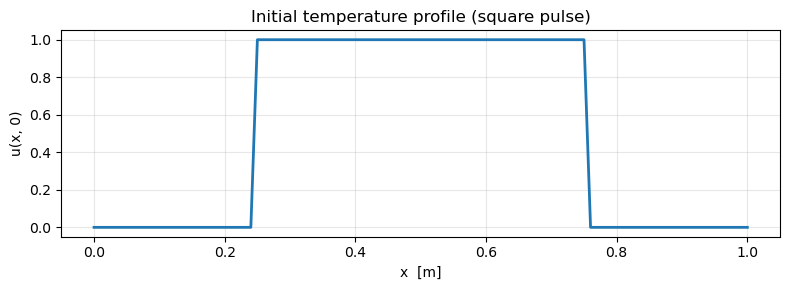

In [2]:
def initial_condition(x, L):
    f = np.zeros_like(x)
    f[(x >= L/4) & (x <= 3*L/4)] = 1.0
    return f

u0 = initial_condition(x, L)

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(x, u0, lw=2)
ax.set_xlabel('x  [m]'); ax.set_ylabel('u(x, 0)')
ax.set_title('Initial temperature profile (square pulse)')
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Analytical solution via Fourier series

For the square-pulse initial condition above, the coefficients integrate to

$$B_n = \frac{2}{L}\int_{L/4}^{3L/4} \sin\!\left(\frac{n\pi x}{L}\right) dx = \frac{2}{n\pi}\left[\cos(n\pi/4) - \cos(3n\pi/4)\right].$$

The truncation order $N$ trades accuracy near the discontinuity (Gibbs phenomenon) for cost. We pick $N = 200$.

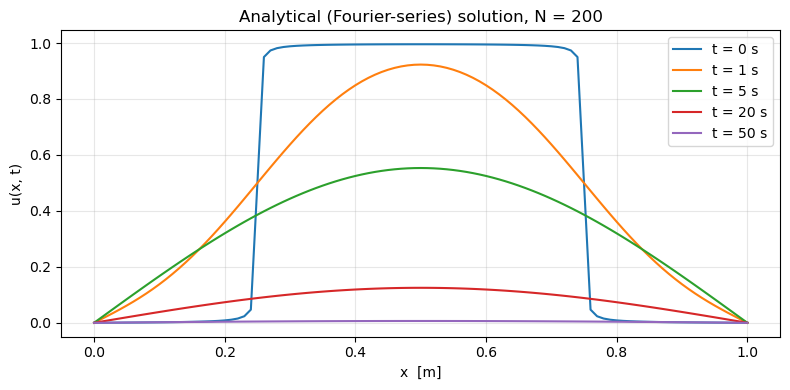

In [3]:
def analytical_solution(x, t, L, alpha, N=200):
    """Truncated Fourier-series solution for the square-pulse IC."""
    n = np.arange(1, N + 1)[:, None]                              # shape (N, 1)
    Bn = (2.0 / (n * np.pi)) * (np.cos(n*np.pi/4) - np.cos(3*n*np.pi/4))
    decay = np.exp(-alpha * (n*np.pi/L)**2 * t)                   # shape (N, 1)
    modes = np.sin(n * np.pi * x / L)                             # shape (N, Nx)
    return (Bn * decay * modes).sum(axis=0)                       # shape (Nx,)

snapshots = [0.0, 1.0, 5.0, 20.0, 50.0]
fig, ax = plt.subplots(figsize=(8, 4))
for t in snapshots:
    ax.plot(x, analytical_solution(x, t, L, alpha), label=f't = {t:.0f} s')
ax.set_xlabel('x  [m]'); ax.set_ylabel('u(x, t)')
ax.set_title('Analytical (Fourier-series) solution, N = 200')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Numerical solution via explicit FTCS

Forward in time, centred in space:

$$u_i^{k+1} = u_i^k + r\,\bigl(u_{i+1}^k - 2 u_i^k + u_{i-1}^k\bigr).$$

Boundary nodes are pinned at $u = 0$ (Dirichlet).

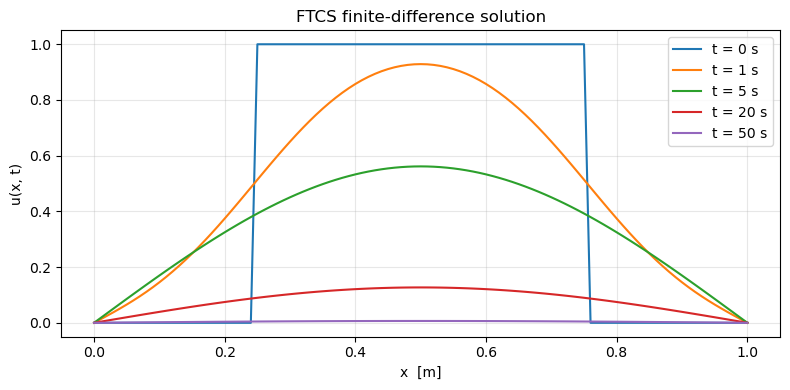

In [4]:
def ftcs_solution(u0, alpha, dx, dt, T_end):
    Nt = int(T_end / dt)
    r  = alpha * dt / dx**2
    assert r <= 0.5, f"FTCS unstable: r = {r:.3f}"
    u  = u0.copy()
    snapshots = {0.0: u.copy()}
    for k in range(Nt):
        u_new           = u.copy()
        u_new[1:-1]     = u[1:-1] + r * (u[2:] - 2*u[1:-1] + u[:-2])
        u_new[0]        = 0.0
        u_new[-1]       = 0.0
        u               = u_new
        if (k+1) * dt in (1.0, 5.0, 20.0, 50.0):
            snapshots[(k+1) * dt] = u.copy()
    return snapshots

snaps_num = ftcs_solution(u0, alpha, dx, dt, T_end=50.0)

fig, ax = plt.subplots(figsize=(8, 4))
for t, u in snaps_num.items():
    ax.plot(x, u, label=f't = {t:.0f} s')
ax.set_xlabel('x  [m]'); ax.set_ylabel('u(x, t)')
ax.set_title('FTCS finite-difference solution')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Side-by-side comparison

The two solutions agree visually at every snapshot. The Fourier-series solution shows mild Gibbs ringing near the corners of the original step at $t = 0$ and $t = 1$ s; the FTCS solution does not, because the discrete Laplacian acts as a low-pass smoother. Both converge to the same long-time profile.

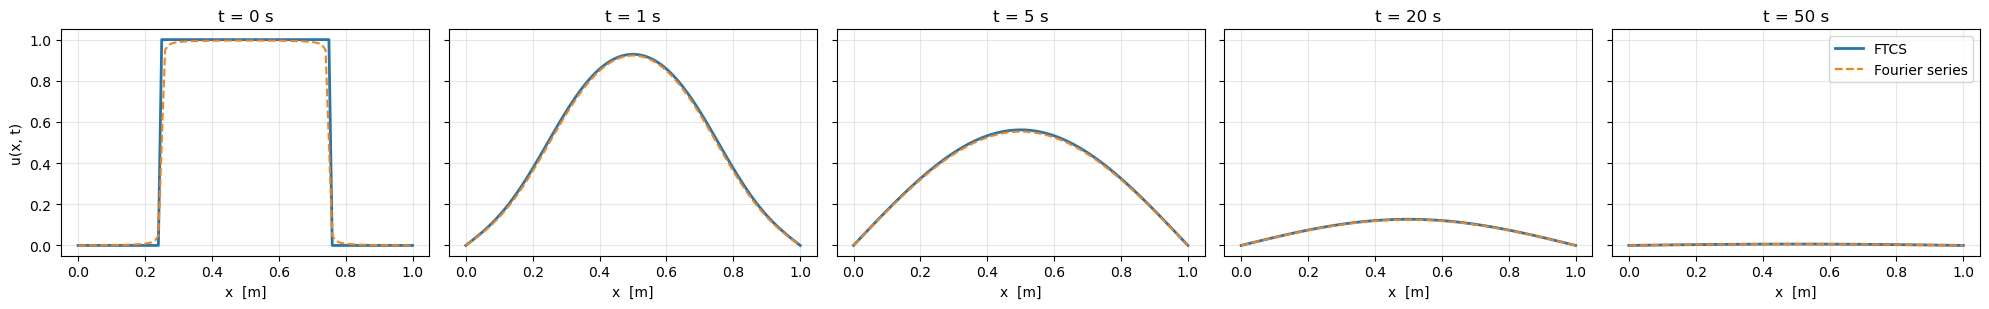

RMS error at t = 50 s : 6.856e-05


In [5]:
fig, axes = plt.subplots(1, len(snaps_num), figsize=(4*len(snaps_num), 3.2), sharey=True)
for ax, (t, u_num) in zip(axes, snaps_num.items()):
    u_ana = analytical_solution(x, t, L, alpha)
    ax.plot(x, u_num, lw=2, label='FTCS')
    ax.plot(x, u_ana, '--', lw=1.5, label='Fourier series')
    ax.set_title(f't = {t:.0f} s')
    ax.set_xlabel('x  [m]')
    ax.grid(alpha=0.3)
axes[0].set_ylabel('u(x, t)')
axes[-1].legend()
plt.tight_layout(); plt.show()

# L2 error vs analytical at the longest time:
u_num_end = snaps_num[50.0]
u_ana_end = analytical_solution(x, 50.0, L, alpha)
err = np.sqrt(np.mean((u_num_end - u_ana_end)**2))
print(f"RMS error at t = 50 s : {err:.3e}")

## Take-aways

- The diffusion equation smooths discontinuities **instantaneously**: even at the smallest plotted time the corners of the square pulse have softened. This is the physical behaviour Fourier was modelling, and it is why he needed a representation that could ingest a discontinuous initial condition (Stein & Shakarchi, 2003, §1).
- The Fourier-series solution decomposes the temperature field into spatial modes whose amplitudes decay **independently** at rates $\exp(-\alpha(n\pi/L)^2 t)$. High-frequency modes ($n$ large) decay much faster than low-frequency ones, which is why the long-time profile is dominated by the first sine.
- The FTCS scheme is conditionally stable. Doubling $\Delta t$ (and thus $r$) above $0.5$ would cause the assertion to fire — try it.
- The agreement between the two solutions, modulo Gibbs ringing, is the practical demonstration that the spectral and finite-difference perspectives are equivalent representations of the same physical law.